# ТЗ
Реализация стохастических градиентных методов с $AdaGrad$ и $AdamW$.
Подходы к борьбе с переобучением:
- Отложенная выборка (Hold-out Validation): Техника однократного разбиения исходного множества на изолированные подмножества. Если тестовое подмножество используется исключительно для финальной фиксации метрик качества, процедура корректна. Если же по отложенной выборке подбираются гиперпараметры ($\lambda$) или принимается решение о досрочной остановке (Early Stopping), для предотвращения утечки данных (data leakage) применяется трехкомпонентное разбиение: Train (настройка весов), Validation (оптимизация $\lambda$, Early Stopping) и Test (финальный независимый аудит).
- (НЕ ВКЛЮЧЕНА, но одна из опций) Кросс-валидация (K-Fold Cross-Validation): Циклическое разбиение данных на $K$ равных блоков (фолдов). На каждой из $K$ итераций модель обучается на $K-1$ блоках, а тестируется на оставшемся одном. Метод минимизирует дисперсию оценки качества модели, что критически важно при малом объеме выборки.Математическая формулировка целевых функций (для одного шага оптимизации):При расчете функционала ошибки на мини-батче размерностью $B$, целевые функции оптимизации для AdaGrad принимают вид:
- L1-регуляризация (аппроксимация Lasso штрафа):$$J_{L1} = \frac{1}{B} \sum_{i=1}^B (y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^M |w_j|$$
- L2-регуляризация (Ridge-штраф):$$J_{L2} = \frac{1}{B} \sum_{i=1}^B (y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^M w_j^2$$Где $B$ - размер текущего батча, $M$ - количество признаков, а вектор весов $w$ не включает в себя свободный член (bias).

Разъяснение по AdamW: для AdamW регуляризация не добавляется в функционал ошибки $J_{L2}$, а реализуется через механизм расцепленного спада весов (Decoupled Weight Decay) непосредственно на этапе обновления параметров:
$$w_{t+1} = w_t - \eta \lambda w_t - \text{Adam}(\nabla_w J_{MSE})$$Это изолирует адаптивный шаг обучения от влияния градиентов L2-нормы.

# Импорт библиотек, датасета, hold-out validation

In [1]:
import copy
import os
import itertools
import sys
import time
from pathlib import Path
import numpy as np
import pandas as pd
import scipy.stats as stats
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
CONFIG = {
    "EPOCHS": 200,                         # Количество эпох обучения
    "BATCH_SIZE": 64,                      # Размер мини-батча
    "LEARNING_RATES": [0.01, 0.05, 0.1],   # Список темпов обучения (lr)
    "LAMBDAS": [0.0001, 0.001, 0.01, 0.1], # Падает до 0, если reg == None
    "REG_TYPES": ["L1", "L2", "None"],
    "OPTIMIZERS": ["AdaGrad", "AdamW"],
    "SEED": 67,
}

In [3]:
# Находим нужный сэмплированный датасет
target_relative_path = Path("..") / "Dataset (Farhat)" / "dataset_sample_1000.csv"
dataset_path = target_relative_path.resolve()

if not dataset_path.exists():
    print(f"Критическая ошибка: Файл не найден.")
    print(f"Ожидаемый абсолютный путь: {dataset_path}")
    print("Проверьте корректность имени папки")
    sys.exit(1)
print(f"Успешно обнаружен файл датасета по пути: {dataset_path}")

Успешно обнаружен файл датасета по пути: /Users/test/Desktop/Various_Linear_Regression_Factors/Dataset (Farhat)/dataset_sample_1000.csv


In [4]:
# устанавливаем сиды для воспроизводимости эксперимента
torch.manual_seed(CONFIG["SEED"])
np.random.seed(CONFIG["SEED"])

df = pd.read_csv(dataset_path)
X_raw = df.drop(columns=['Цена_log']).values
y_raw = df['Цена_log'].values.reshape(-1, 1)

# Разбиение на train/test=80/20 (Hold-out validation)
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=CONFIG["SEED"]
)

# Стандартизируе фичи
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train_raw)
X_test_scaled = scaler_X.transform(X_test_raw)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train_raw)
y_test_scaled = scaler_y.transform(y_test_raw)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32)

# DataLoader для стохастического градиентного спуска (Mini-Batch SGD)
# Нужен в условиях больших датасетов, когда нельзя сразу обработать все данные
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=CONFIG["BATCH_SIZE"], shuffle=True)

# Сетка параметров
CONFIG["LAMBDAS"] = np.logspace(-3, 1, num=5)
INPUT_DIM = X_train_tensor.shape[1]  # количество фич

# Структура для логирования кривых обучения
history_data = {}

# Построение baselines 

## Обычное среднее (стандартизированное)

In [5]:
mean_train_pred = np.full_like(y_train_scaled, np.mean(y_train_scaled))
mean_test_pred = np.full_like(y_test_scaled, np.mean(y_train_scaled))

mse_mean_train = mean_squared_error(y_train_scaled, mean_train_pred)
mse_mean_test = mean_squared_error(y_test_scaled, mean_test_pred)
history_data["Baseline_Mean"] = {
    "train": [mse_mean_train] * CONFIG["EPOCHS"],
    "test": [mse_mean_test] * CONFIG["EPOCHS"],
    "final_test": mse_mean_test
}

## МНК (без, с L1, L2 регуляризациями)

In [6]:
# МНК без регуляризаций:
ols_pure = LinearRegression().fit(X_train_scaled, y_train_scaled)
mse_ols_train = mean_squared_error(y_train_scaled, ols_pure.predict(X_train_scaled))
mse_ols_test = mean_squared_error(y_test_scaled, ols_pure.predict(X_test_scaled))
history_data["Baseline_OLS_Pure"] = {
    "train": [mse_ols_train] * CONFIG["EPOCHS"],
    "test": [mse_ols_test] * CONFIG["EPOCHS"],
    "final_test": mse_ols_test
}

# МНК с регуляризациями 
for lmbda in CONFIG["LAMBDAS"]:
    # L1 (Lasso) 
    lasso = Lasso(alpha=lmbda, max_iter=10000).fit(X_train_scaled, y_train_scaled)
    mse_l1_train = mean_squared_error(y_train_scaled, lasso.predict(X_train_scaled).reshape(-1, 1))
    mse_l1_test = mean_squared_error(y_test_scaled, lasso.predict(X_test_scaled).reshape(-1, 1))
    history_data[f"Baseline_OLS_L1_lambda_{lmbda:.4f}"] = {
        "train": [mse_l1_train] * CONFIG["EPOCHS"],
        "test": [mse_l1_test] * CONFIG["EPOCHS"],
        "final_test": mse_l1_test
    }
    
    # L2 (Ridge)
    ridge = Ridge(alpha=lmbda).fit(X_train_scaled, y_train_scaled)
    mse_l2_train = mean_squared_error(y_train_scaled, ridge.predict(X_train_scaled))
    mse_l2_test = mean_squared_error(y_test_scaled, ridge.predict(X_test_scaled))
    history_data[f"Baseline_OLS_L2_lambda_{lmbda:.4f}"] = {
        "train": [mse_l2_train] * CONFIG["EPOCHS"],
        "test": [mse_l2_test] * CONFIG["EPOCHS"],
        "final_test": mse_l2_test
    }

# Использование оптимизаторов (библиотечное)

## *AdaGrad* (Adaptive Gradient Algorithm)
- Суть: Алгоритм адаптирует темп обучения покоординатно, масштабируя текущий градиент обратно пропорционально корню из суммы квадратов всех исторических градиентов данного параметра. Это позволяет делать большие шаги по редким (разреженным) признакам и уменьшать шаг по часто обновляемым.

Математический шаг оптимизации:
Пусть $g_t = \nabla_{\theta} L(\theta_t)$ - градиент функции потерь по весам $\theta$ на шаге $t$. Аккумуляция квадратов градиентов $G_t \in \mathbb{R}^d$ и обновление параметров выполняются покоординатно (оператор $\odot$ обозначает умножение Адамара):
$$ G_t = G_{t-1} + g_t \odot g_t $$
$$ \theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{G_t} + \epsilon} \odot g_t $$
Где $\eta$ - базовый темп обучения, а $\epsilon > 0$ - сглаживающий параметр, предотвращающий деление на ноль (в реализации torch.optim.Adagrad по умолчанию $\epsilon = 10^{-10}$). Монотонное возрастание компонент вектора $G_t$ гарантирует монотонное убывание эффективного шага.

## AdamW (Adam with Decoupled Weight Decay)
- Суть: модификация классического алгоритма Adam, которая изолирует (расцепляет) механизм регуляризации от процесса адаптации темпа обучения. Adam комбинирует идеи накопления импульса (Momentum) и покоординатного масштабирования шага (RMSProp), вычисляя экспоненциально затухающие средние прошлых градиентов ($m_t$) и их квадратов ($v_t$). В отличие от Adam, где L2-штраф модифицирует градиент, AdamW выполняет спад весов (Weight Decay) напрямую на этапе обновления параметров.
- Математический шаг оптимизации: Пусть $g_t = \nabla_{\theta} L_{MSE}(\theta_t)$ - градиент функции потерь по весам $\theta$ на шаге $t$, рассчитанный без учета регуляризационных штрафов.
Вычисление смещенных оценок первого (усредненный градиент) и второго (нецентрированная дисперсия) моментов:
$$m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t$$
$$v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t \odot g_t$$
Коррекция смещения моментов для компенсации инициализации нулями ($m_0 = 0, v_0 = 0$):
$$\hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1 - \beta_2^t}$$
Модификация шага параметров и финальное обновление (механизм Decoupled Weight Decay):
$$\theta_{t+1} = \theta_t \cdot (1 - \eta \lambda) - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \odot \hat{m}_t$$

где:
$\eta$ - базовый темп обучения (lr);
$\lambda$ - коэффициент спада весов (weight_decay);
$\beta_1, \beta_2$ - коэффициенты затухания моментов (канонические значения: $\beta_1=0.9, \beta_2=0.999$);
$\epsilon$ - сглаживающий параметр для численной стабильности (в torch.optim.AdamW по умолчанию $\epsilon = 10^{-8}$).

- Отличие от классического Adam: если в обычном Adam использовать параметр weight_decay, алгоритм преобразует градиент: $g^{new}_t = g_t + \lambda \theta_t$. В этом случае штраф подмешивается в моменты $m_t$ и $v_t$. Из-за деления на $\sqrt{v_t}$ в адаптивном шаге веса, которые исторически имели большие градиенты, будут штрафоваться меньше, чем веса с маленькими градиентами. AdamW решает данную проблему, выполняя линейный спад веса $\theta_t \cdot (1 - \eta \lambda)$ независимо от накопленной динамики градиентов.

In [7]:
keys = ["opt", "reg", "lr"]
combinations = itertools.product(
    CONFIG["OPTIMIZERS"],
    CONFIG["REG_TYPES"],
    CONFIG["LEARNING_RATES"]
)
configurations = [dict(zip(keys, comb)) for comb in combinations]
for config in configurations:
    opt_name = config["opt"]
    reg_type = config["reg"]
    learning_rate = config["lr"]
    
    for lmbda in CONFIG["LAMBDAS"]:
        # не имеет смысла рассматривать больше 1 лямбды
        if reg_type == "None" and lmbda != CONFIG["LAMBDAS"][0]:
            continue
        # Инициализируем воспроизводимое состояние сети
        # (с каждой итерацией сид "сдвигается", фиксируем его)        
        torch.manual_seed(CONFIG["SEED"])
        model = nn.Linear(INPUT_DIM, 1)
        criterion = nn.MSELoss()
        
        wd_param = lmbda if reg_type == "L2" else 0.0
        if opt_name == "AdaGrad":
            optimizer = optim.Adagrad(model.parameters(), lr=learning_rate, weight_decay=wd_param)
        elif opt_name == "AdamW":
            optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=wd_param)
            
        train_epochs_loss = []
        test_epochs_loss = []

        start_time = time.time()
        # Фиксирование лучшего состояния модели на валидации
        best_test_mse = float("inf")
        best_model_state = None
        
        # Стохастический мини-батч цикл обучения
        for epoch in range(CONFIG["EPOCHS"]):
            model.train()
            for batch_X, batch_y in train_loader:
                # обнулять градиент можно реже, аккумулируя градиент - требует меньше памяти, если батч большой
                # однако здесь размер батча небольшой
                optimizer.zero_grad(set_to_none=True)
                predictions = model(batch_X)
                loss = criterion(predictions, batch_y)
                if reg_type == "L1":
                    loss += lmbda * model.weight.abs().sum()
                loss.backward()
                optimizer.step()
                
            model.eval()
            # torch.no_grad() - отключает построение графа вычислений
            # граф вычислений здесь не нужен, поэтому можем сэкономить память и ускорить
            with torch.no_grad():
                current_train_mse = criterion(model(X_train_tensor), y_train_tensor).item()
                current_test_mse = criterion(model(X_test_tensor), y_test_tensor).item()
            train_epochs_loss.append(current_train_mse)
            test_epochs_loss.append(current_test_mse)
            
            # Сохранение весов лучшей итерации
            if current_test_mse < best_test_mse:
                best_test_mse = current_test_mse
                best_model_state = copy.deepcopy(model.state_dict())
        
        elapsed_time = time.time() - start_time
        exp_key = f"{opt_name}_{reg_type}_lr_{learning_rate}_lambda_{lmbda:.4f}"
        history_data[exp_key] = {
            "train": train_epochs_loss,
            "test": test_epochs_loss,
            "final_test": test_epochs_loss[-1],
            "time": elapsed_time,
            "best_mse": best_test_mse,
            "best_state": best_model_state,
            "lr": learning_rate,    
            "opt": opt_name,
            "reg": reg_type
        }

# Графики MSE/CONFIG["EPOCHS"]

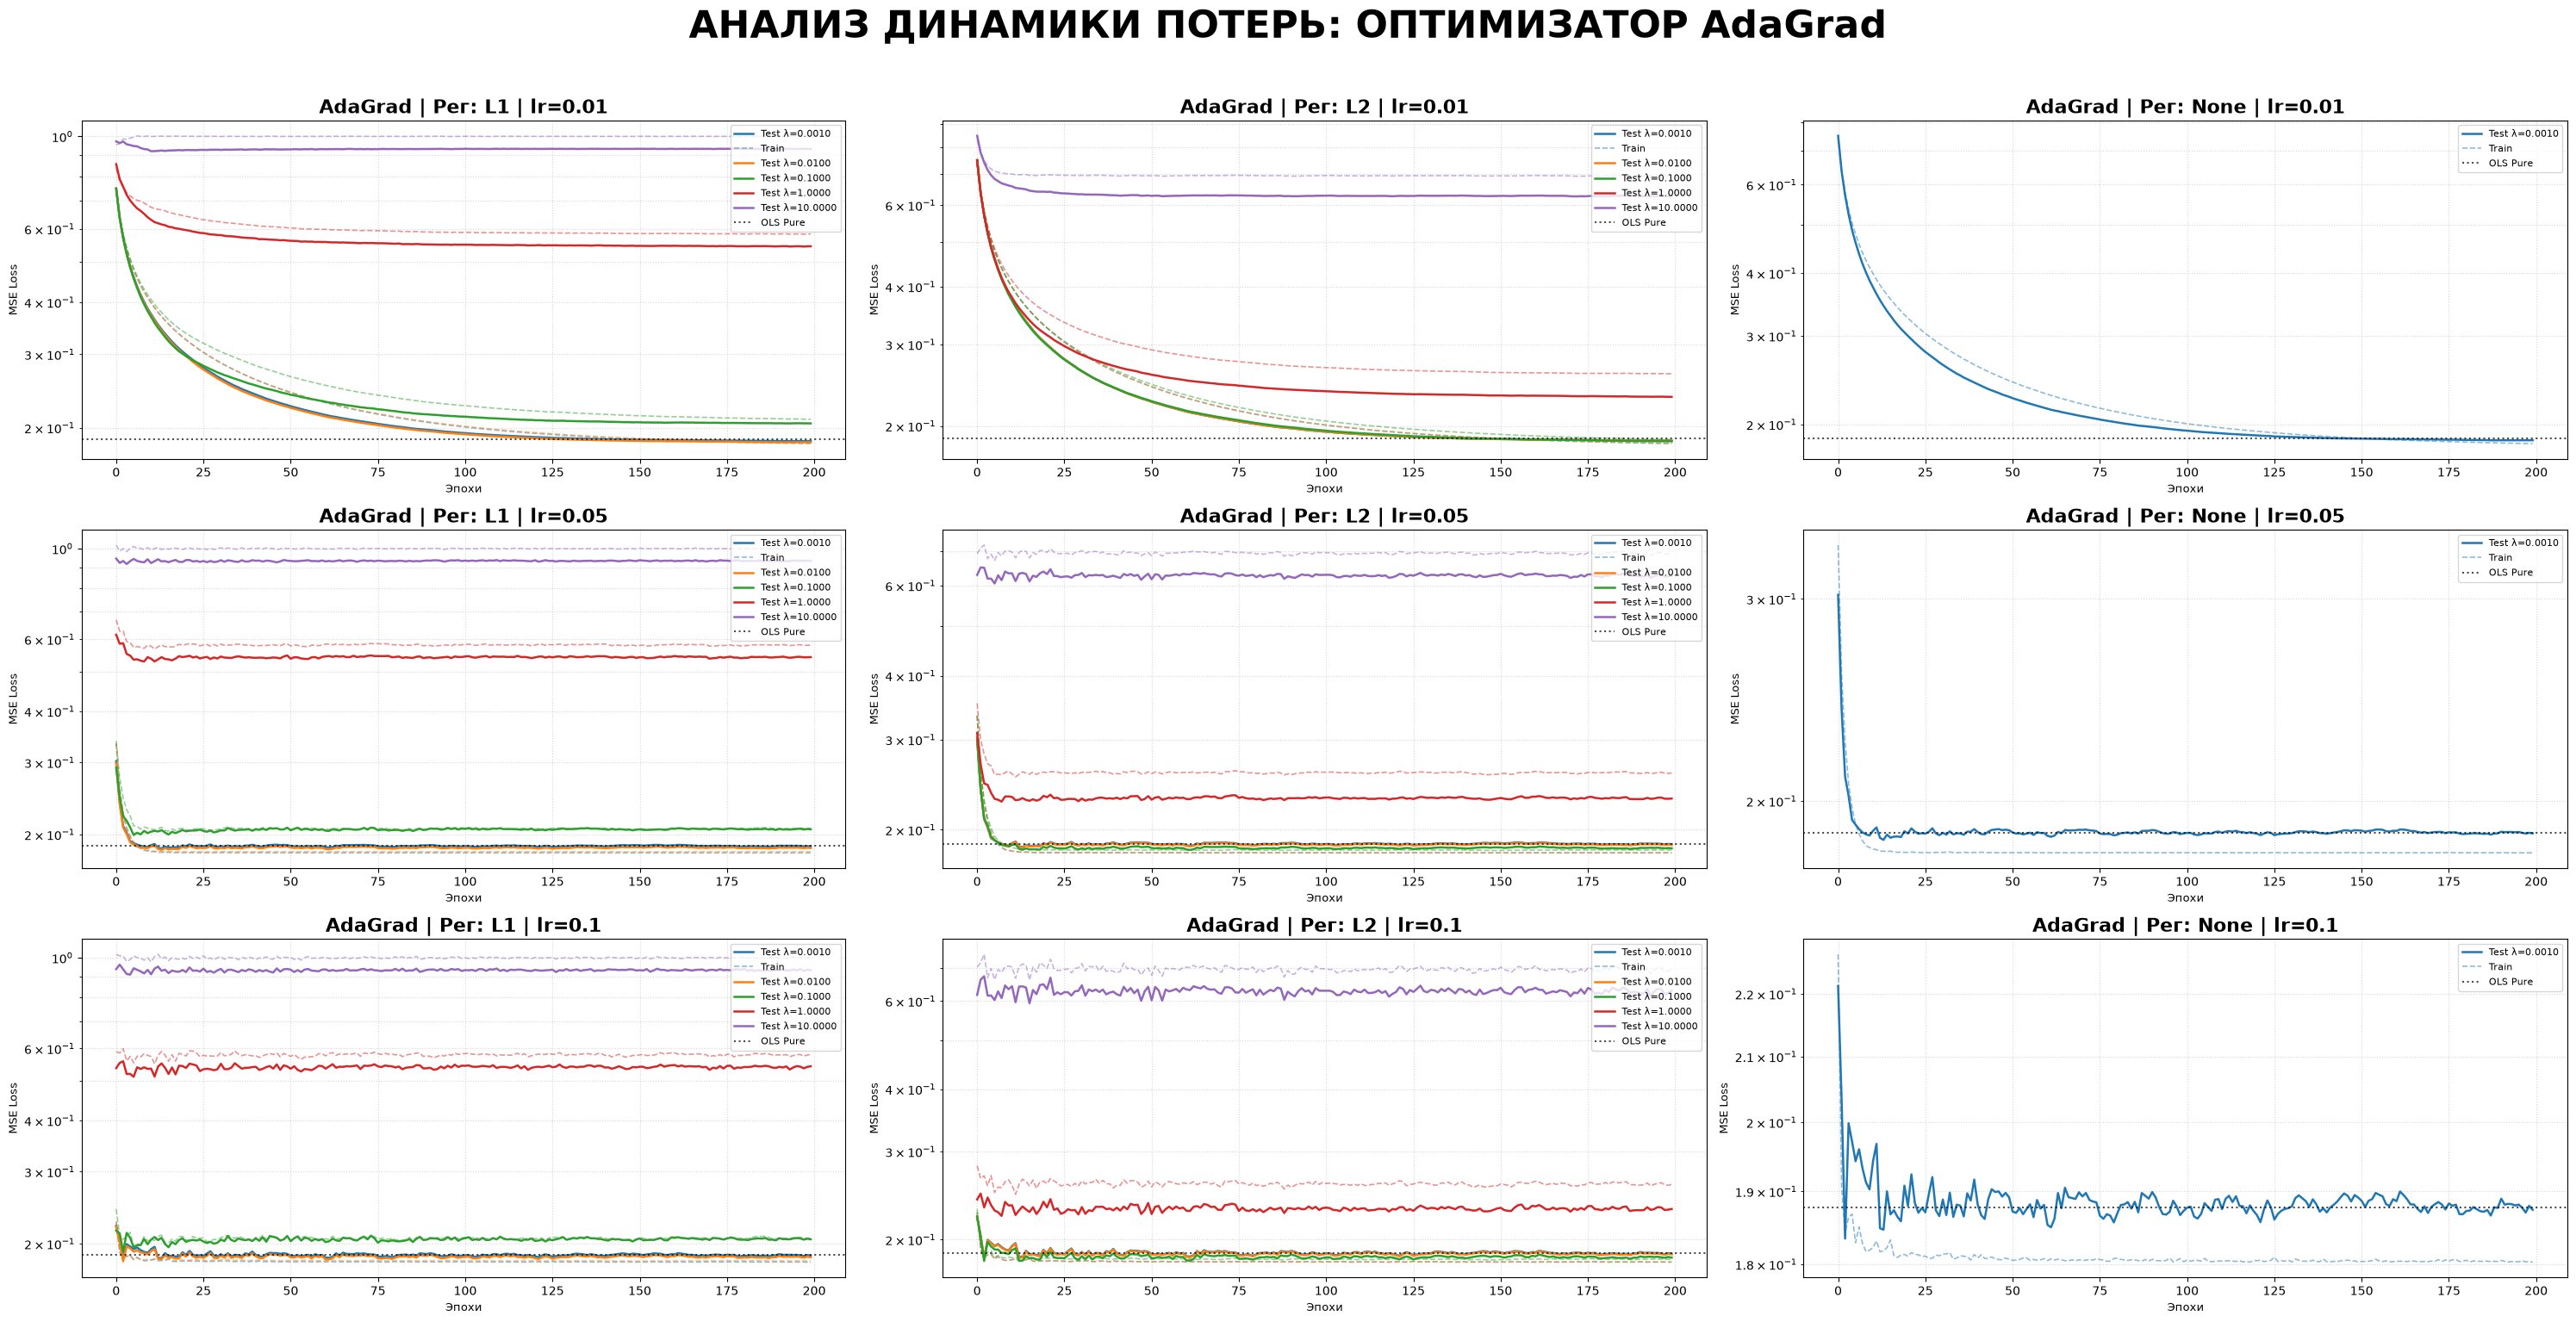

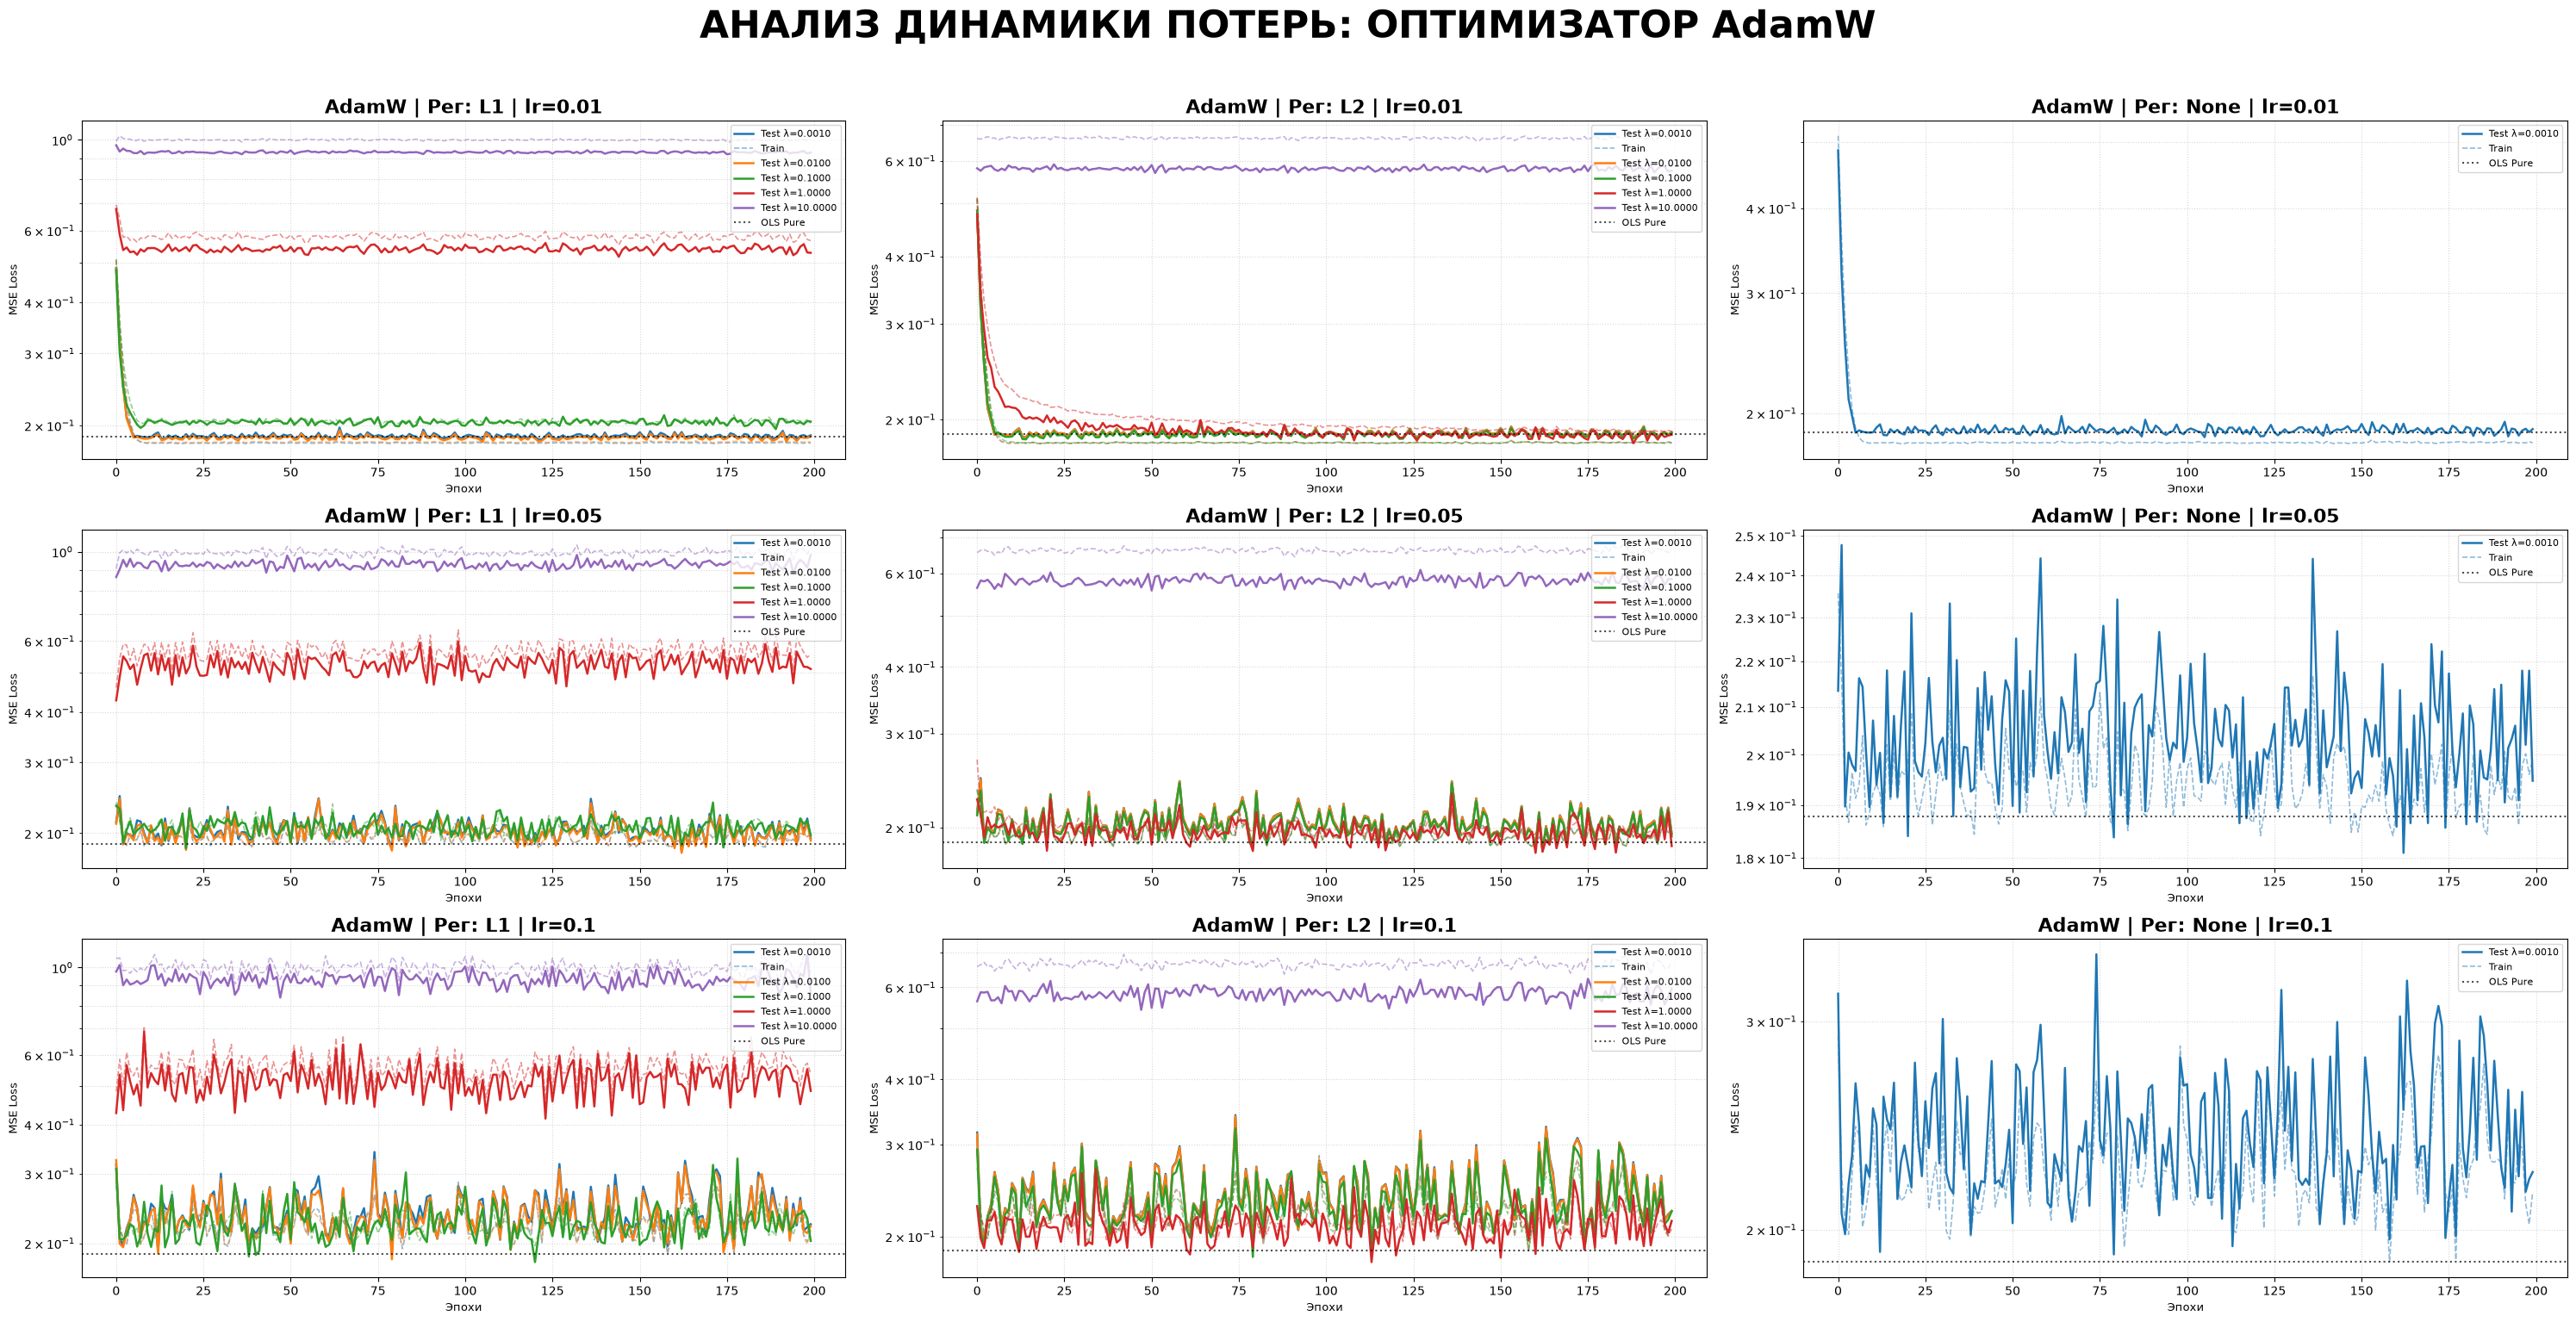

In [8]:
learning_rates = CONFIG["LEARNING_RATES"]
reg_types = CONFIG["REG_TYPES"]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Графики для AdaGrad (3 строки по lr, 3 столбца по рег)
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
fig1, axes1 = plt.subplots(
    len(learning_rates), 
    len(reg_types), 
    figsize=(30, 5 * len(learning_rates))
)
for row_i, lr in enumerate(learning_rates):
    for col_i, reg_type in enumerate(reg_types):
        ax = axes1[row_i, col_i]
        ax.set_title(f"AdaGrad | Рег: {reg_type} | lr={lr}", fontsize=16, fontweight='bold')
        for i, lmbda in enumerate(CONFIG["LAMBDAS"]):
            if reg_type == "None" and i > 0: 
                continue
            exp_key = f"AdaGrad_{reg_type}_lr_{lr}_lambda_{lmbda:.4f}"
            if exp_key in history_data:
                curves = history_data[exp_key]
                ax.plot(curves["test"], color=colors[i], linestyle='-', linewidth=1.8, label=f'Test λ={lmbda:.4f}')
                if i == 0:
                    ax.plot(curves["train"], color=colors[i], linestyle='--', alpha=0.5, linewidth=1.2, label='Train')
                else:
                    ax.plot(curves["train"], color=colors[i], linestyle='--', alpha=0.5, linewidth=1.2)
        if "Baseline_OLS_Pure" in history_data:
            ols_data = history_data["Baseline_OLS_Pure"]["test"]
            ols_val = ols_data[0] if isinstance(ols_data, list) else ols_data
            ax.axhline(y=ols_val, color="black", linestyle=":", alpha=0.7, label="OLS Pure")
        ax.set_xlabel("Эпохи", fontsize=9)
        ax.set_ylabel("MSE Loss", fontsize=9)
        ax.set_yscale('log')
        ax.grid(True, which="both", linestyle=':', alpha=0.5)
        handles, labels = ax.get_legend_handles_labels()
        if handles:
            ax.legend(loc='upper right', fontsize=8)

fig1.suptitle("АНАЛИЗ ДИНАМИКИ ПОТЕРЬ: ОПТИМИЗАТОР AdaGrad", fontsize=32, fontweight='bold', y=1.02)
fig1.tight_layout()
plt.show()

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Графики для AdamW (3 строки по lr, 3 столбца по рег)
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
fig2, axes2 = plt.subplots(
    len(learning_rates), 
    len(reg_types), 
    figsize=(30, 5 * len(learning_rates)) 
)
for row_i, lr in enumerate(learning_rates):
    for col_i, reg_type in enumerate(reg_types):
        ax = axes2[row_i, col_i]
        ax.set_title(f"AdamW | Рег: {reg_type} | lr={lr}", fontsize=16, fontweight='bold')
        for i, lmbda in enumerate(CONFIG["LAMBDAS"]):
            if reg_type == "None" and i > 0: 
                continue
            exp_key = f"AdamW_{reg_type}_lr_{lr}_lambda_{lmbda:.4f}"
            if exp_key in history_data:
                curves = history_data[exp_key]
                ax.plot(curves["test"], color=colors[i], linestyle='-', linewidth=1.8, label=f'Test λ={lmbda:.4f}')
                if i == 0:
                    ax.plot(curves["train"], color=colors[i], linestyle='--', alpha=0.5, linewidth=1.2, label='Train')
                else:
                    ax.plot(curves["train"], color=colors[i], linestyle='--', alpha=0.5, linewidth=1.2)
        if "Baseline_OLS_Pure" in history_data:
            ols_data = history_data["Baseline_OLS_Pure"]["test"]
            ols_val = ols_data[0] if isinstance(ols_data, list) else ols_data
            ax.axhline(y=ols_val, color="black", linestyle=":", alpha=0.7, label="OLS Pure")
        ax.set_xlabel("Эпохи", fontsize=9)
        ax.set_ylabel("MSE Loss", fontsize=9)
        ax.set_yscale('log')
        ax.grid(True, which="both", linestyle=':', alpha=0.5)
        handles, labels = ax.get_legend_handles_labels()
        if handles:
            ax.legend(loc='upper right', fontsize=8)
            
fig2.suptitle("АНАЛИЗ ДИНАМИКИ ПОТЕРЬ: ОПТИМИЗАТОР AdamW", fontsize=32, fontweight='bold', y=1.02)
fig2.tight_layout()
plt.show()

# HEATMAP

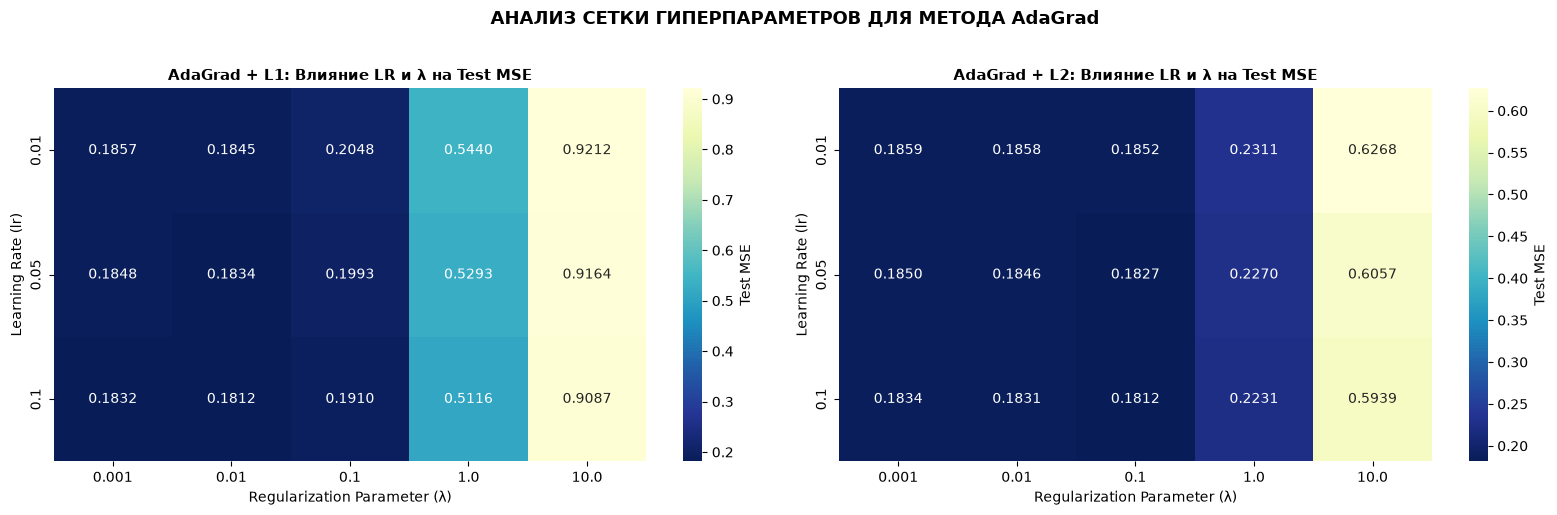

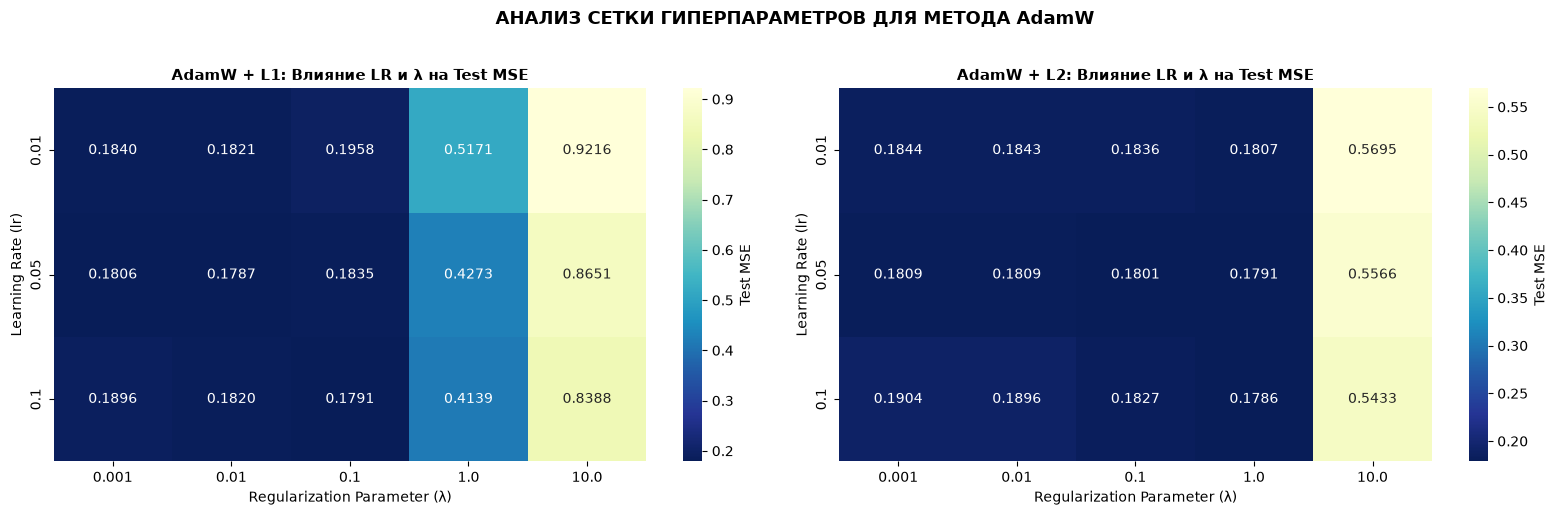

In [9]:
records = []
for key, value in history_data.items():
    if "lr" in value:  # минусуем OLS бейзлайны если они в общем словаре
        records.append({
            "Optimizer": value["opt"],
            "Reg_Type": value["reg"],
            "LR": value["lr"],
            "Lambda": float(key.split("_lambda_")[1]) if "lambda_" in key else 0.0,
            "Test_MSE": value["best_mse"]
        })

df_grid = pd.DataFrame(records)
# тепловые карты влияния гиперпараметров
for opt in CONFIG["OPTIMIZERS"]:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    for idx, reg in enumerate(["L1", "L2"]):
        # Выбираем подвыборку для конкретного оптимизатора и регуляризации
        df_sub = df_grid[(df_grid["Optimizer"] == opt) & (df_grid["Reg_Type"] == reg)]
        pivot_df = df_sub.pivot(index="LR", columns="Lambda", values="Test_MSE")
        
        ax = axes[idx]
        # fmt=".4f" выведет MSE текстом внутри ячеек
        sns.heatmap(pivot_df, annot=True, fmt=".4f", cmap="YlGnBu_r", ax=ax, cbar_kws={'label': 'Test MSE'})
        ax.set_title(f"{opt} + {reg}: Влияние LR и λ на Test MSE", fontweight='bold', fontsize=11)
        ax.set_ylabel("Learning Rate (lr)")
        ax.set_xlabel("Regularization Parameter (λ)")
        
    plt.suptitle(f"АНАЛИЗ СЕТКИ ГИПЕРПАРАМЕТРОВ ДЛЯ МЕТОДА {opt}", fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

# Выбор best ols

In [10]:
def mape_score(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def smape_score(y_true, y_pred):
    return np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred))) * 100

def to_original_scale(y_scaled, scaler):
    # скейлим так, чтобы избежать ошибок в размерности
    y_2d = y_scaled.reshape(-1, 1)
    y_unscaled = scaler.inverse_transform(y_2d)
    return np.expm1(y_unscaled).flatten()


def evaluate_model_all_scales(y_pred_scaled, num_features, zeroed_count):
    # избегаем бродкастинг sklearn
    y_pred_scaled_flat = y_pred_scaled.flatten()
    
    # метрики на стандартизированной логарифмической шкале
    mse = mean_squared_error(y_test_scaled_flat, y_pred_scaled_flat)
    r2 = r2_score(y_test_scaled_flat, y_pred_scaled_flat)
    adj_r2 = 1 - (1 - r2) * (n_samples - 1) / (n_samples - num_features - 1)
    mae = mean_absolute_error(y_test_scaled_flat, y_pred_scaled_flat)
    
    # рассччет на исходной шкале цен
    y_pred_original = to_original_scale(y_pred_scaled_flat, scaler_y)
    mae_orig = mean_absolute_error(y_test_original, y_pred_original)
    mape_orig = mape_score(y_test_original, y_pred_original)
    smape_orig = smape_score(y_test_original, y_pred_original)
    return {
        "R2": r2,
        "Adj_R2": adj_r2,
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "MAE": mae,
        "MAE_orig": mae_orig,
        "MAPE_orig": mape_orig,
        "SMAPE_orig": smape_orig,
        "Sparsity": (zeroed_count / num_features) * 100,
        "preds_orig": y_pred_original
    }


# подгонка истинных значений
y_test_scaled_flat = y_test_scaled.flatten()
y_test_original = to_original_scale(y_test_scaled_flat, scaler_y)

ols_metrics = {}
n_samples = X_test_scaled.shape[0]
p_features = X_test_scaled.shape[1]

# Среднее
mean_pred_scaled = np.full_like(y_test_scaled_flat, np.mean(y_train_scaled))
ols_metrics["Mean_Baseline"] = evaluate_model_all_scales(mean_pred_scaled, 1, 1)

# МНК без регуляризации
ols_pure = LinearRegression().fit(X_train_scaled, y_train_scaled)
ols_metrics["OLS_Pure"] = evaluate_model_all_scales(ols_pure.predict(X_test_scaled), p_features, 0)

# МНК Lasso (L1)
best_lasso_mse = float("inf")
best_lasso_pred = None
best_lasso_zeroed = 0
for lmbda in CONFIG["LAMBDAS"]:
    lasso = Lasso(alpha=lmbda, max_iter=10000).fit(X_train_scaled, y_train_scaled)
    pred = lasso.predict(X_test_scaled)
    mse = mean_squared_error(y_test_scaled_flat, pred.flatten())
    if mse < best_lasso_mse:
        best_lasso_mse = mse
        best_lasso_pred = pred
        best_lasso_zeroed = np.sum(lasso.coef_ == 0)
ols_metrics["OLS_Lasso"] = evaluate_model_all_scales(best_lasso_pred, p_features, best_lasso_zeroed)

# МНК Ridge (L2)
best_ridge_mse = float("inf")
best_ridge_pred = None
for lmbda in CONFIG["LAMBDAS"]:
    ridge = Ridge(alpha=lmbda).fit(X_train_scaled, y_train_scaled)
    pred = ridge.predict(X_test_scaled)
    mse = mean_squared_error(y_test_scaled_flat, pred.flatten())
    if mse < best_ridge_mse:
        best_ridge_mse = mse
        best_ridge_pred = pred
ols_metrics["OLS_Ridge"] = evaluate_model_all_scales(best_ridge_pred, p_features, 0)

# выбор лучшей модели по логарифмическому MSE
models_keys = ols_metrics.keys()
best_ols_model = min(models_keys, key=lambda m: ols_metrics[m]["MSE"])
print(f"{'~'*25}\nНаилучшая модель: {best_ols_model} с ошибкой {ols_metrics[best_ols_model]['MSE']:.6f}\n{'~'*25}")

~~~~~~~~~~~~~~~~~~~~~~~~~
Наилучшая модель: OLS_Lasso с ошибкой 0.186159
~~~~~~~~~~~~~~~~~~~~~~~~~


## Визуализация среднего + вариаций МНК

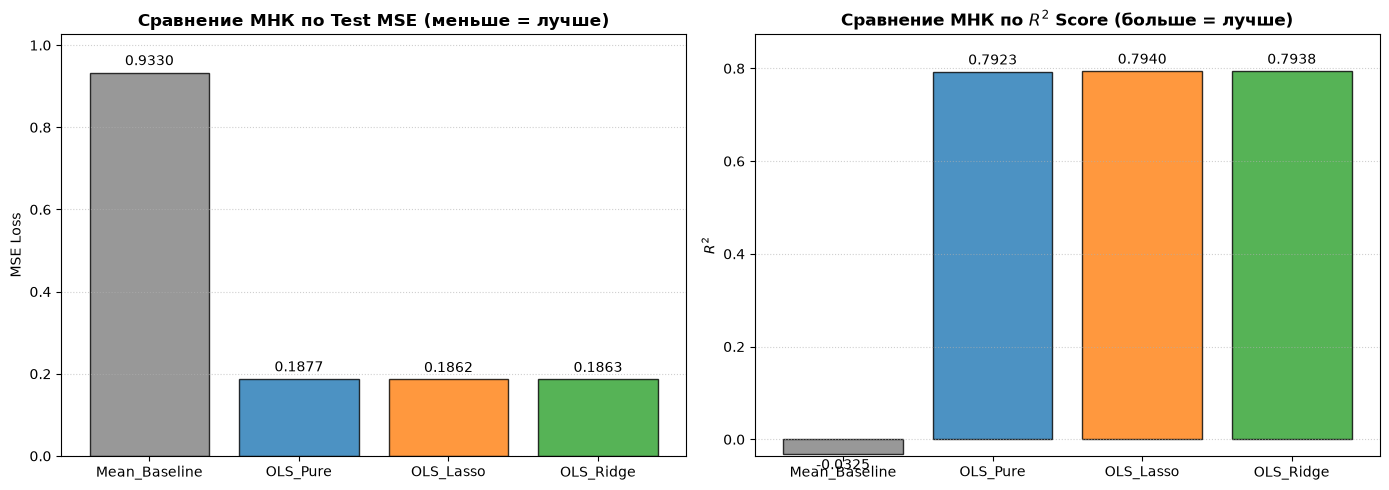

In [11]:
models_keys = list(ols_metrics.keys())
mse_values = [ols_metrics[k]["MSE"] for k in models_keys]
r2_values = [ols_metrics[k]["R2"] for k in models_keys]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors_v = ['#7f7f7f', '#1f77b4', '#ff7f0e', '#2ca02c']

# левый график (MSE)
bars1 = ax1.bar(models_keys, mse_values, color=colors_v, alpha=0.8, edgecolor='black')
ax1.set_title("Сравнение МНК по Test MSE (меньше = лучше)", fontweight='bold')
ax1.set_ylabel("MSE Loss")
ax1.grid(axis='y', linestyle=':', alpha=0.6)
ax1.bar_label(bars1, padding=3, fmt='%.4f') 

# Правый график (R2)
bars2 = ax2.bar(models_keys, r2_values, color=colors_v, alpha=0.8, edgecolor='black')
ax2.set_title("Сравнение МНК по $R^2$ Score (больше = лучше)", fontweight='bold')
ax2.set_ylabel("$R^2$")
ax2.grid(axis='y', linestyle=':', alpha=0.6)
ax2.bar_label(bars2, padding=3, fmt='%.4f') 

ax1.set_ylim(0, max(mse_values) * 1.1)
ax2.set_ylim(min(r2_values) * 1.1 if min(r2_values) < 0 else 0, max(r2_values) * 1.1)

plt.tight_layout()
plt.show()

# Сравнение AdaGrad, AdamW с бейзлайнами

In [12]:
def get_best_nn_metrics(opt_name, reg_type):
    best_key = None
    min_mse = float("inf")
    for lr in CONFIG["LEARNING_RATES"]:
        for lmbda in CONFIG["LAMBDAS"]:
            # пропускаем лишние комбинации для None
            if reg_type == "None" and lmbda != CONFIG["LAMBDAS"][0]:
                continue
            key = f"{opt_name}_{reg_type}_lr_{lr}_lambda_{lmbda:.4f}"
            if key in history_data and history_data[key]["best_mse"] < min_mse:
                min_mse = history_data[key]["best_mse"]
                best_key = key
    # if best_key is None:
    #     # Заглушка на случай если данных по конфигурации нет
    #     return {"R2": 0.0, "MSE": 1.0, "RMSE": 1.0, "MAE": 1.0, "Sparsity": 0.0}
            
    best_state = history_data[best_key]["best_state"]
    final_model = nn.Linear(INPUT_DIM, 1)
    final_model.load_state_dict(best_state)
    final_model.eval()
    with torch.no_grad():
        preds = final_model(X_test_tensor).numpy().flatten()
        weights = final_model.weight.numpy().flatten()
        
    y_test_scaled_flat = y_test_scaled.flatten()
    zeroed_weights = np.sum(np.abs(weights) < 1e-4)
    mse = mean_squared_error(y_test_scaled_flat, preds)
    return {
        "R2": r2_score(y_test_scaled_flat, preds),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "MAE": mean_absolute_error(y_test_scaled_flat, preds),
        "Sparsity": (zeroed_weights / len(weights)) * 100,
        "weights": weights,       
        "predictions": preds      
    }


final_comparison = {}
counter = 1
if "Mean_Baseline" in ols_metrics:
    final_comparison[f"{counter}. Mean Baseline"] = ols_metrics["Mean_Baseline"]
    counter += 1
if 'best_ols_model' in locals() and best_ols_model in ols_metrics:
    final_comparison[f"{counter}. Best OLS ({best_ols_model})"] = ols_metrics[best_ols_model]
    counter += 1
elif "OLS_Pure" in ols_metrics:
    final_comparison[f"{counter}. Best OLS (OLS_Pure)"] = ols_metrics["OLS_Pure"]
    counter += 1

for opt in CONFIG["OPTIMIZERS"]:
    for reg in CONFIG["REG_TYPES"]:
        # для None вывод - один раз, не дублируя под каждую комбинацию
        if reg == "None" and f"{counter-1}. {opt} (Best None)" in final_comparison:
            continue
        label_name = f"{counter}. {opt} (Best {reg})"
        final_comparison[label_name] = get_best_nn_metrics(opt, reg)
        counter += 1

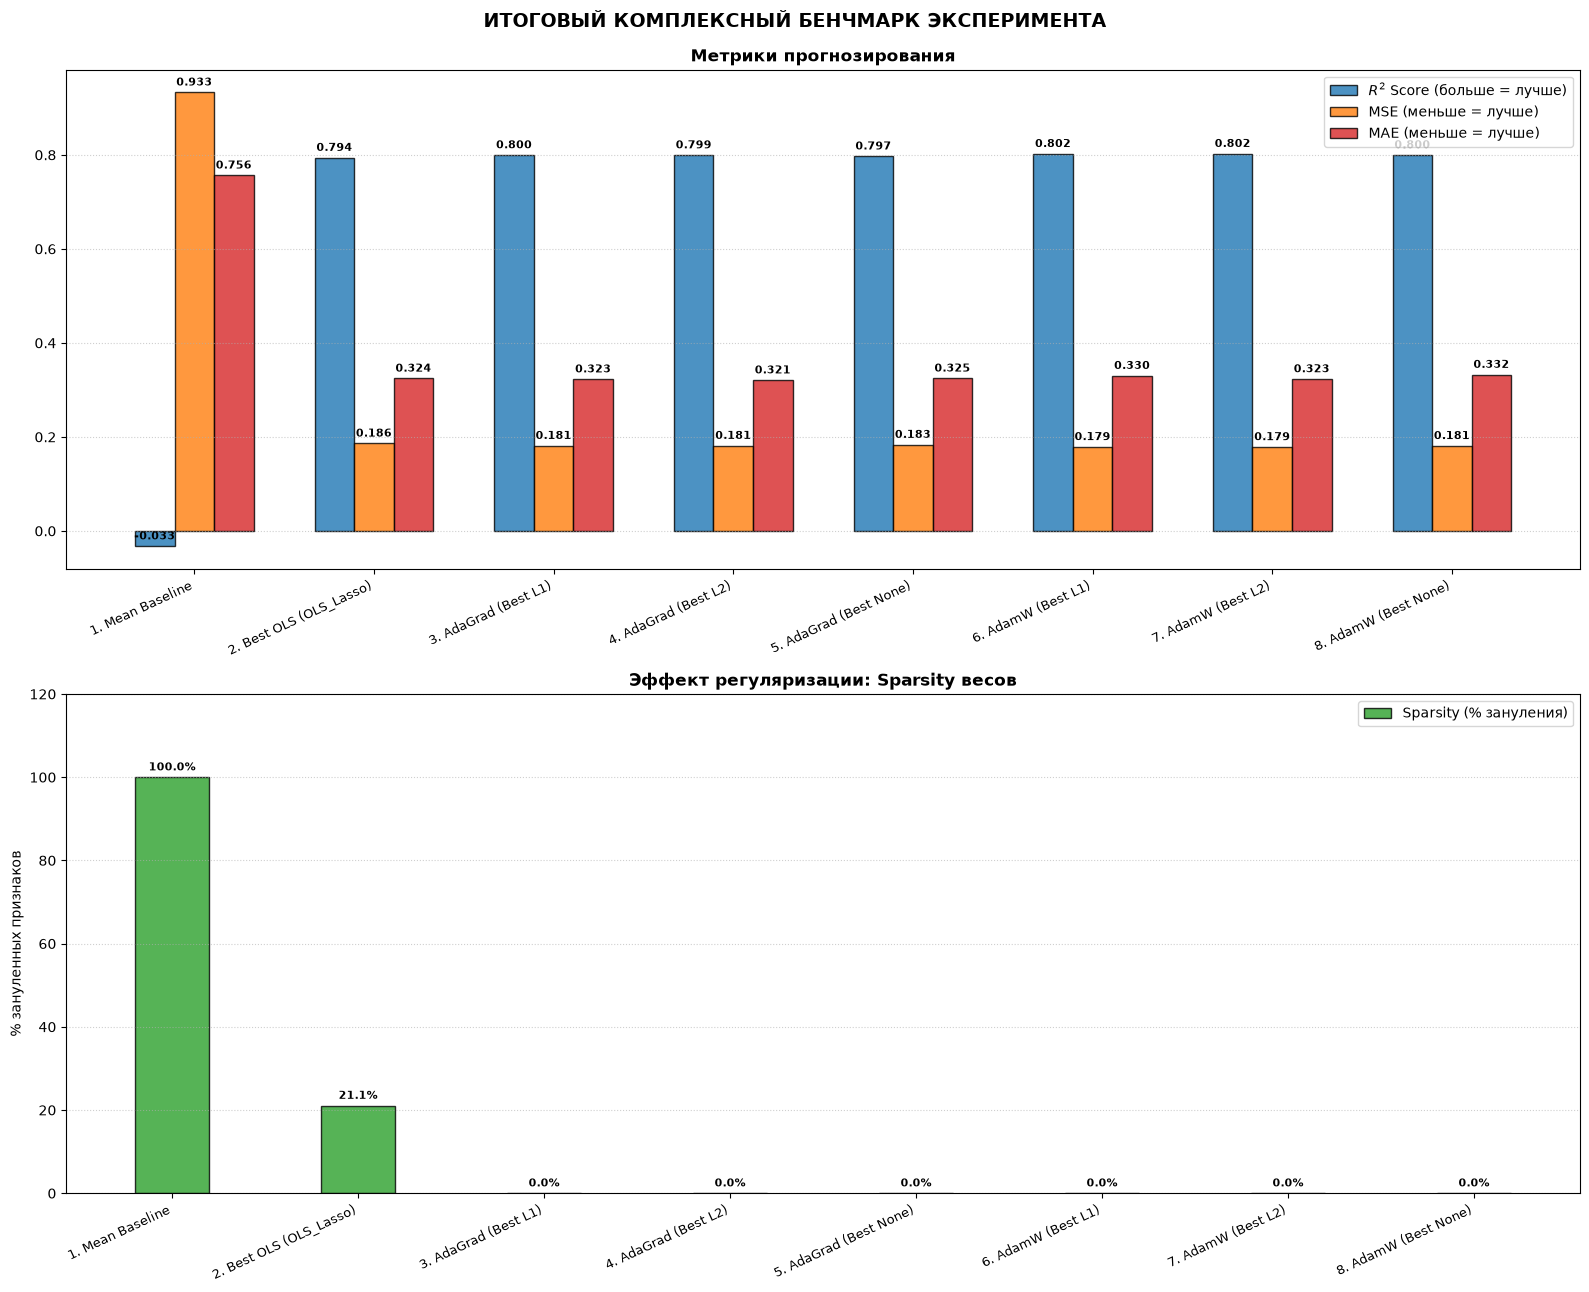


~~~~~~~~~~~~~~~~~~~~~~~~~ АНАЛИЗ ЭФФЕКТИВНОСТИ МЕТОДОВ БОРЬБЫ С ПЕРЕОБУЧЕНИЕМ ~~~~~~~~~~~~~~~~~~~~~~~~~
1. Mean Baseline                 | R2: -0.0325 | MSE: 0.9330 | MAE: 0.7564 | Спарсити весов: 100.0%
2. Best OLS (OLS_Lasso)          | R2: 0.7940 | MSE: 0.1862 | MAE: 0.3244 | Спарсити весов: 21.1%
3. AdaGrad (Best L1)             | R2: 0.7995 | MSE: 0.1812 | MAE: 0.3227 | Спарсити весов: 0.0%
4. AdaGrad (Best L2)             | R2: 0.7994 | MSE: 0.1812 | MAE: 0.3206 | Спарсити весов: 0.0%
5. AdaGrad (Best None)           | R2: 0.7970 | MSE: 0.1835 | MAE: 0.3245 | Спарсити весов: 0.0%
6. AdamW (Best L1)               | R2: 0.8022 | MSE: 0.1787 | MAE: 0.3301 | Спарсити весов: 0.0%
7. AdamW (Best L2)               | R2: 0.8024 | MSE: 0.1786 | MAE: 0.3231 | Спарсити весов: 0.0%
8. AdamW (Best None)             | R2: 0.7998 | MSE: 0.1809 | MAE: 0.3324 | Спарсити весов: 0.0%
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


In [13]:
def autolabel(rects, ax):
    for rect in rects:
        height = rect.get_height()
        if abs(height) > 1e-4:
            ax.annotate(f'{height:.3f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),  # Смещение на 3 пункта по вертикали вверх
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=8, fontweight='bold')


labels = list(final_comparison.keys())
r2_scores = [final_comparison[k]["R2"] for k in labels]
mse_scores = [final_comparison[k]["MSE"] for k in labels]
mae_scores = [final_comparison[k]["MAE"] for k in labels]
sparsity_scores = [final_comparison[k]["Sparsity"] for k in labels]

x = np.arange(len(labels))
width = 0.22

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 13))
# ~~~~~~~~~~~~~~ ВЕРХНИЙ ГРАФИК: МЕТРИКИ КАЧЕСТВА ~~~~~~~~~~~~~~
rects1 = ax1.bar(x - width, r2_scores, width, label='$R^2$ Score (больше = лучше)', color='#1f77b4', alpha=0.8, edgecolor='black')
rects2 = ax1.bar(x, mse_scores, width, label='MSE (меньше = лучше)', color='#ff7f0e', alpha=0.8, edgecolor='black')
rects3 = ax1.bar(x + width, mae_scores, width, label='MAE (меньше = лучше)', color='#d62728', alpha=0.8, edgecolor='black')

ax1.set_title("Метрики прогнозирования", fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=25, ha="right", fontsize=9)
ax1.grid(axis='y', linestyle=':', alpha=0.6)
ax1.legend(loc='upper right')

autolabel(rects1, ax1)
autolabel(rects2, ax1)
autolabel(rects3, ax1)

# ~~~~~~~~~~~~~~ НИЖНИЙ ГРАФИК: РАЗРЕЖЕННОСТЬ (SPARSITY) ~~~~~~~~~~~~~~
rects4 = ax2.bar(x, sparsity_scores, width=0.4, label='Sparsity (% зануления)', color='#2ca02c', alpha=0.8, edgecolor='black')

ax2.set_title("Эффект регуляризации: Sparsity весов", fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(labels, rotation=25, ha="right", fontsize=9)
ax2.set_ylabel("% зануленных признаков")
ax2.set_ylim(0, 120)
ax2.grid(axis='y', linestyle=':', alpha=0.6)
ax2.legend(loc='upper right')

for rect in rects4:
    height = rect.get_height()
    ax2.annotate(f'{height:.1f}%',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.suptitle("ИТОГОВЫЙ КОМПЛЕКСНЫЙ БЕНЧМАРК ЭКСПЕРИМЕНТА", fontsize=14, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()

print("\n" + "~"*25 + " АНАЛИЗ ЭФФЕКТИВНОСТИ МЕТОДОВ БОРЬБЫ С ПЕРЕОБУЧЕНИЕМ " + "~"*25)
for model_name, metrics in final_comparison.items():
    print(f"{model_name:<32} | R2: {metrics['R2']:.4f} | MSE: {metrics['MSE']:.4f} | MAE: {metrics['MAE']:.4f} | Спарсити весов: {metrics['Sparsity']:.1f}%")
print("~"*105)

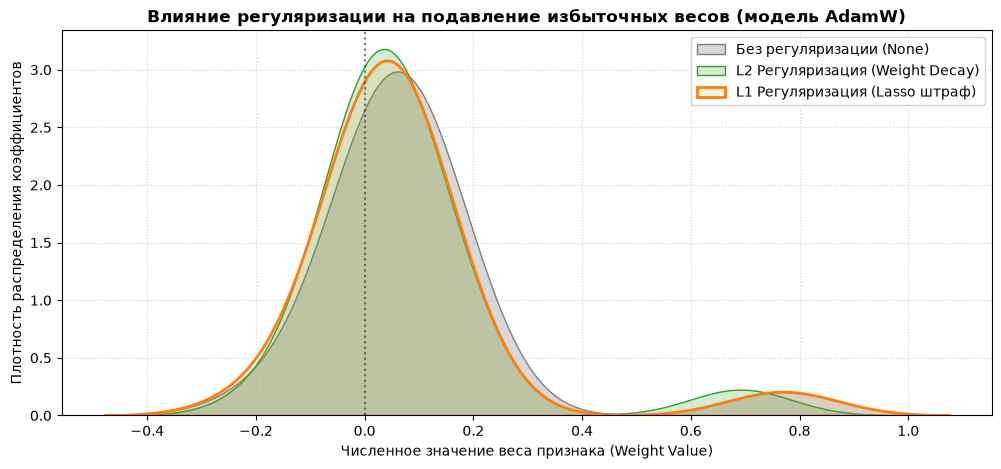

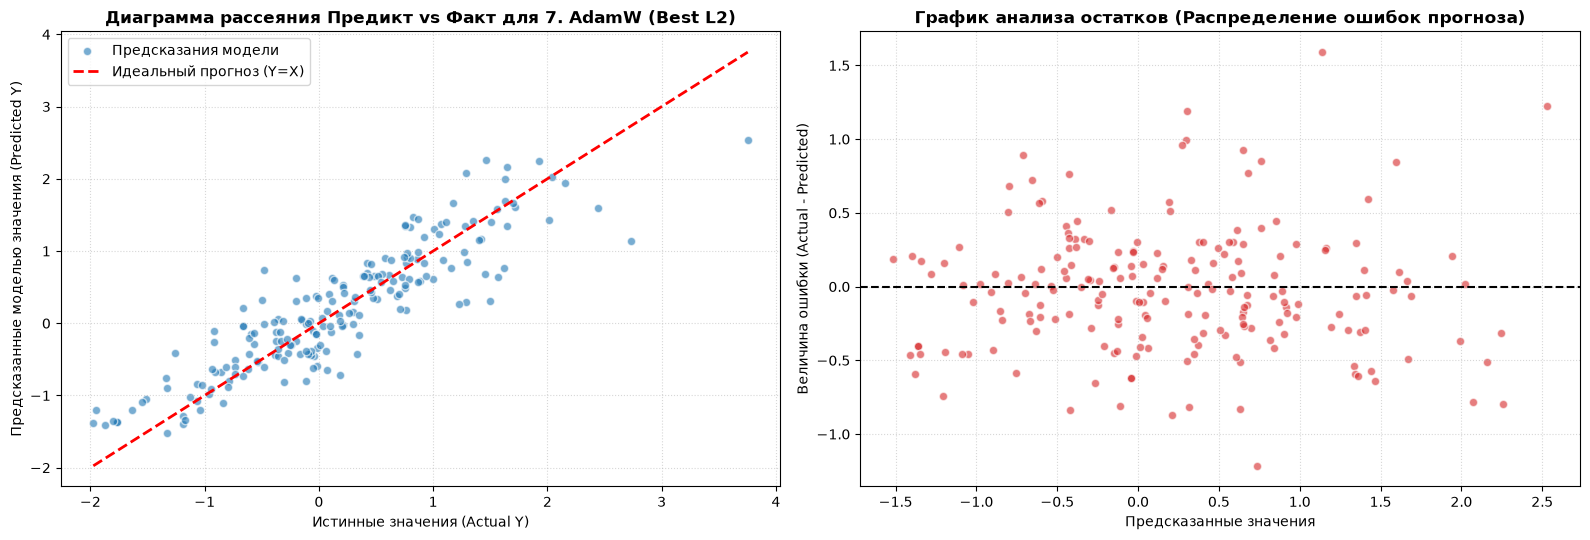

In [14]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~[ГРАФИК 1] СРАВНЕНИЕ РАСПРЕДЕЛЕНИЯ ВЕСОВ~~~~~~~~~~~~~~~~~~~~~~~~~~
plt.figure(figsize=(12, 5))
weights_none = final_comparison["8. AdamW (Best None)"]["weights"]
weights_l1 = final_comparison["6. AdamW (Best L1)"]["weights"]
weights_l2 = final_comparison["7. AdamW (Best L2)"]["weights"]

# гладкие графики плотности распределения весов
sns.kdeplot(weights_none, label="Без регуляризации (None)", color="#7f7f7f", fill=True, alpha=0.3)
sns.kdeplot(weights_l2, label="L2 Регуляризация (Weight Decay)", color="#2ca02c", fill=True, alpha=0.2)
sns.kdeplot(weights_l1, label="L1 Регуляризация (Lasso штраф)", color="#ff7f0e", fill=True, alpha=0.1, linewidth=2)

plt.title("Влияние регуляризации на подавление избыточных весов (модель AdamW)", fontweight='bold', fontsize=12)
plt.xlabel("Численное значение веса признака (Weight Value)")
plt.ylabel("Плотность распределения коэффициентов")
plt.axvline(x=0, color='black', linestyle=':', alpha=0.5)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend()
plt.show()


#~~~~~~~~~~~~~~~~~~~~~~~~~~[ГРАФИК 2] АНАЛИЗ ПРЕДСКАЗАНИЙ "ПРЕДИКТ vs ФАКТ" / ГРАФИК ОСТАТКОВ~~~~~~~~~~~~~~~~~~~~~~~~~~
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
# берем лучшую модель по результатам бенчмарка
best_model_key = "7. AdamW (Best L2)" 
best_preds = final_comparison[best_model_key]["predictions"]
y_test_true = y_test_scaled.flatten() 

# [левый график] предикт против факта
ax1 = axes[0]
ax1.scatter(y_test_true, best_preds, color='#1f77b4', alpha=0.6, edgecolors='w', label='Предсказания модели')

ideal_line = [min(y_test_true), max(y_test_true)]
ax1.plot(ideal_line, ideal_line, color='red', linestyle='--', linewidth=2, label='Идеальный прогноз (Y=X)')
ax1.set_title(f"Диаграмма рассеяния Предикт vs Факт для {best_model_key}", fontweight='bold')
ax1.set_xlabel("Истинные значения (Actual Y)")
ax1.set_ylabel("Предсказанные моделью значения (Predicted Y)")
ax1.grid(True, linestyle=':', alpha=0.5)
ax1.legend()

# [правый график] распределение остатков (ошибок)
residuals = y_test_true - best_preds
ax2 = axes[1]
ax2.scatter(best_preds, residuals, color='#d62728', alpha=0.6, edgecolors='w')
ax2.axhline(y=0, color='black', linestyle='--', linewidth=1.5)
ax2.set_title("График анализа остатков (Распределение ошибок прогноза)", fontweight='bold')
ax2.set_xlabel("Предсказанные значения")
ax2.set_ylabel("Величина ошибки (Actual - Predicted)")
ax2.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

Успешно найдена лучшая конфигурация: AdamW_L2_lr_0.1_lambda_1.0000 (Best Test MSE: 0.17858)


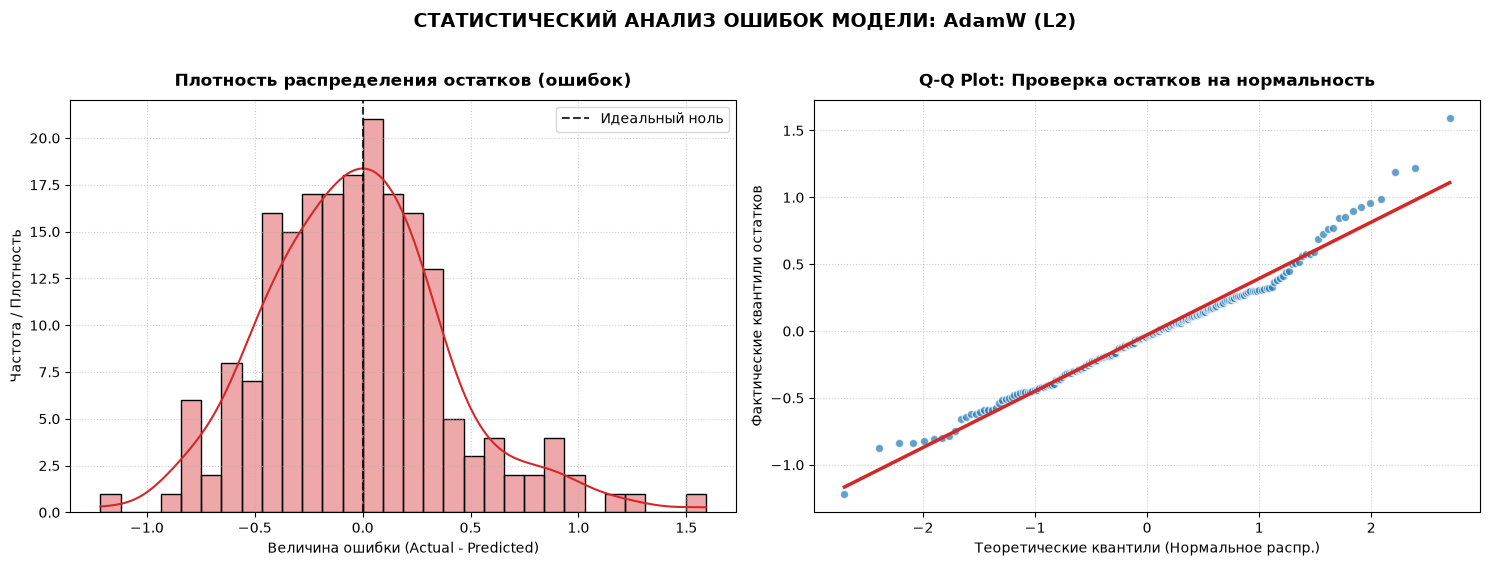

In [15]:
# Поиск лучшей модели
target_opt = "AdamW"
target_reg = "L2"
best_key = None
min_mse = float("inf")
for key, data in history_data.items():
    if data.get("opt") == target_opt and data.get("reg") == target_reg:
        if "best_mse" in data and data["best_mse"] < min_mse:
            min_mse = data["best_mse"]
            best_key = key
if best_key is None:
    raise ValueError(f"В history_data не найдено конфигураций для {target_opt} + {target_reg}")
print(f"Успешно найдена лучшая конфигурация: {best_key} (Best Test MSE: {min_mse:.5f})")

# извлечение весов и генерация предсказаний на тест-выборке
best_state = history_data[best_key]["best_state"]
final_model = nn.Linear(INPUT_DIM, 1)
final_model.load_state_dict(best_state)
final_model.eval()
with torch.no_grad():
    preds = final_model(X_test_tensor).numpy().flatten()
# вычисляем остатки 
y_test_flat = y_test_scaled.flatten()
residuals = y_test_flat - preds

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))
#~~~~~~~~~~~~~~~~~~~~~~~~~~[ЛЕВЫЙ ГРАФИК] Распределение остатков (Гистограмма + Плотность)~~~~~~~~~~~~~~~~~~~~~~~~~~
sns.histplot(residuals, kde=True, color='#d62728', alpha=0.4, ax=ax1, bins=30, edgecolor='black')
ax1.axvline(x=0, color='black', linestyle='--', alpha=0.8, linewidth=1.5, label='Идеальный ноль')
ax1.set_title("Плотность распределения остатков (ошибок)", fontweight='bold', fontsize=12, pad=10)
ax1.set_xlabel("Величина ошибки (Actual - Predicted)")
ax1.set_ylabel("Частота / Плотность")
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend()

#~~~~~~~~~~~~~~~~~~~~~~~~~~[ПРАВЫЙ ГРАФИК] Q-Q Plot (Квантиль-Квантиль)~~~~~~~~~~~~~~~~~~~~~~~~~~
stats.probplot(residuals, dist="norm", plot=ax2)
ax2.get_lines()[0].set_markerfacecolor('#1f77b4')
ax2.get_lines()[0].set_markeredgecolor('white')
ax2.get_lines()[0].set_alpha(0.7)
ax2.get_lines()[1].set_color('#d62728')
ax2.get_lines()[1].set_linewidth(2.5)

ax2.set_title("Q-Q Plot: Проверка остатков на нормальность", fontweight='bold', fontsize=12, pad=10)
ax2.set_xlabel("Теоретические квантили (Нормальное распр.)")
ax2.set_ylabel("Фактические квантили остатков")
ax2.grid(True, linestyle=':', alpha=0.6)

plt.suptitle(f"СТАТИСТИЧЕСКИЙ АНАЛИЗ ОШИБОК МОДЕЛИ: {target_opt} ({target_reg})", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Ручная реализация оптимизаторов 

## Adagrad

In [18]:
class AdaGradLinearRegression:
    def __init__(self, learning_rate=0.1, epsilon=1e-8):
        self.lr = learning_rate
        self.epsilon = epsilon
        
        # параметры модели (инициализируются при первом запуске)
        self.w = None
        self.b = 0.0
        
        # история градиентов для AdaGrad
        self.G_w = None
        self.G_b = 0.0
        
        # mean и std, чтобы потом правильно нормализовать новые тестовые данные
        self.mean = None
        self.std = None

    def _normalize(self, X):
        """метод для ручной Z-score нормализации"""
        if self.mean is None or self.std is None:
            self.mean = np.mean(X, axis=0)
            self.std = np.std(X, axis=0)
            # Защита от деления на 0
            self.std[self.std == 0] = 1e-8
        return (X - self.mean) / self.std

    def _get_gradient(self, X_scaled, y):
        """метод для ручного расчета градиентов на матрицах"""
        N = X_scaled.shape[0]
        # Прогноз: X * w + b
        predictions = np.dot(X_scaled, self.w) + self.b
        err = predictions - y
        
        # Матричное вычисление градиентов
        grad_w = (2 / N) * np.dot(X_scaled.T, err)
        grad_b = (2 / N) * np.sum(err)
        return grad_w, grad_b

    def __call__(self, X, y, epochs=500, verbose=True):
        """
        Этот метод вызывается в момент ' model(X, y) ',
        запускает полный цикл обучения
        """
        X_scaled = self._normalize(X)
        num_features = X.shape[1]
        # инициализация веса и истории AdaGrad нулями
        if self.w is None:
            self.w = np.zeros(num_features)
            self.G_w = np.zeros(num_features)
            self.G_b = 0.0

        for epoch in range(1, epochs + 1):
            grad_w, grad_b = self._get_gradient(X_scaled, y)
            
            self.G_w += grad_w ** 2
            self.G_b += grad_b ** 2
            
            self.w -= (self.lr / (np.sqrt(self.G_w) + self.epsilon)) * grad_w
            self.b -= (self.lr / (np.sqrt(self.G_b) + self.epsilon)) * grad_b
            
            # Логирование ошибки каждые 50 эпох
            if verbose and (epoch == 1 or epoch % 50 == 0):
                current_preds = np.dot(X_scaled, self.w) + self.b
                mse = np.mean((current_preds - y) ** 2)
                print(f"Эпоха {epoch:3d} | Текущая ошибка (MSE): {mse:.4f}")
        return self.w, self.b

    def predict(self, X):
        if self.w is None:
            raise ValueError("Нет ничего, что можно было бы предсказать")
        X_scaled = (X - self.mean) / self.std
        return np.dot(X_scaled, self.w) + self.b

In [20]:
np.random.seed(69)
X_random = np.random.rand(200, 19) * 100  # например, площади от 0 до 100 кв.м.

true_w = np.random.uniform(-5, 5, size=19)
true_b = 15.0
noise = np.random.normal(0, 2, size=200)
y_random = np.dot(X_random, true_w) + true_b + noise

adagrad_model = AdaGradLinearRegression(learning_rate=0.4, epsilon=1e-8)

print("--- Старт обучения ---")
final_w, final_b = adagrad_model(X_random, y_random, epochs=400)
print("--- Обучение завершено ---\n")

print(f"Истинный b: {true_b}")
print(f"Найденный b: {final_b:.4f}")

--- Старт обучения ---
Эпоха   1 | Текущая ошибка (MSE): 145235.6000
Эпоха  50 | Текущая ошибка (MSE): 131952.0373
Эпоха 100 | Текущая ошибка (MSE): 125768.9845
Эпоха 150 | Текущая ошибка (MSE): 121186.7397
Эпоха 200 | Текущая ошибка (MSE): 117430.4267
Эпоха 250 | Текущая ошибка (MSE): 114199.9234
Эпоха 300 | Текущая ошибка (MSE): 111341.7380
Эпоха 350 | Текущая ошибка (MSE): 108764.9399
Эпоха 400 | Текущая ошибка (MSE): 106410.3951
--- Обучение завершено ---

Истинный b: 15.0
Найденный b: 15.0283


## AdamW

In [21]:
class AdamWLinearRegression:
    def __init__(self, learning_rate=0.05, beta1=0.9, beta2=0.999, epsilon=1e-8, weight_decay=0.01):
        self.lr = learning_rate
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.weight_decay = weight_decay
        
        self.w = None
        self.b = 0.0
        # Первые моменты (m) и вторые моменты (v)
        self.m_w, self.v_w = None, None
        self.m_b, self.v_b = 0.0, 0.0
        # счетчик шагов (нужен для исправления смещения beta^t)
        self.t = 0
        # нормализация
        self.mean = None
        self.std = None

    def _normalize(self, X):
        if self.mean is None or self.std is None:
            self.mean = np.mean(X, axis=0)
            self.std = np.std(X, axis=0)
            self.std[self.std == 0] = 1e-8
        return (X - self.mean) / self.std

    def _get_gradient(self, X_scaled, y):
        N = X_scaled.shape[0]
        predictions = np.dot(X_scaled, self.w) + self.b
        err = predictions - y
        # Чистые градиенты без L2-регуляризации (в AdamW она отделена!)
        grad_w = (2 / N) * np.dot(X_scaled.T, err)
        grad_b = (2 / N) * np.sum(err)
        return grad_w, grad_b

    def __call__(self, X, y, epochs=500, verbose=True):
        X_scaled = self._normalize(X)
        num_features = X.shape[1]
        # инициализация матриц при первом вызове
        if self.w is None:
            self.w = np.zeros(num_features)
            self.m_w = np.zeros(num_features)
            self.v_w = np.zeros(num_features)
            
        for epoch in range(1, epochs + 1):
            self.t += 1  # Увеличиваем шаг для формулы коррекции
            grad_w, grad_b = self._get_gradient(X_scaled, y)
            # шаг для весов (w) 
            self.m_w = self.beta1 * self.m_w + (1 - self.beta1) * grad_w
            self.v_w = self.beta2 * self.v_w + (1 - self.beta2) * (grad_w ** 2)
            
            # так называемый bias correction
            m_w_corrected = self.m_w / (1 - self.beta1 ** self.t)
            v_w_corrected = self.v_w / (1 - self.beta2 ** self.t)
            
            self.w -= self.lr * self.weight_decay * self.w + (self.lr / (np.sqrt(v_w_corrected) + self.epsilon)) * m_w_corrected
            
            # шаг AdamW для b (без weight decay)
            self.m_b = self.beta1 * self.m_b + (1 - self.beta1) * grad_b
            self.v_b = self.beta2 * self.v_b + (1 - self.beta2) * (grad_b ** 2)
            m_b_corrected = self.m_b / (1 - self.beta1 ** self.t)
            b_v_corrected = self.v_b / (1 - self.beta2 ** self.t)
            self.b -= (self.lr / (np.sqrt(b_v_corrected) + self.epsilon)) * m_b_corrected
            # Вывод логов
            if verbose and (epoch == 1 or epoch % 50 == 0):
                current_preds = np.dot(X_scaled, self.w) + self.b
                mse = np.mean((current_preds - y) ** 2)
                print(f"Эпоха {epoch:3d} | MSE: {mse:.4f}")
        return self.w, self.b

    def predict(self, X):
        if self.w is None:
            raise ValueError("Нет ничего, что можно было бы предсказать")
        X_scaled = self._normalize(X)
        return np.dot(X_scaled, self.w) + self.b

In [22]:
np.random.seed(69)
X_rand = np.random.randn(300, 19) * 50

true_weights = np.random.uniform(-3, 3, size=19)
true_bias = 42.0
y_rand = np.dot(X_rand, true_weights) + true_bias + np.random.normal(0, 5, size=300)

adamw_model = AdamWLinearRegression(learning_rate=1.5, weight_decay=0.001)
print("--- Старт обучения AdamW ---")
w_found, b_found = adamw_model(X_rand, y_rand, epochs=500)
print("--- Обучение завершено ---\n")

print(f"Оригинальный b: {true_bias}")
print(f"Найденный b:    {b_found:.4f}\n")

--- Старт обучения AdamW ---
Эпоха   1 | MSE: 148321.4499
Эпоха  50 | MSE: 32936.0631
Эпоха 100 | MSE: 6224.5090
Эпоха 150 | MSE: 1422.9204
Эпоха 200 | MSE: 567.2179
Эпоха 250 | MSE: 364.4971
Эпоха 300 | MSE: 285.2838
Эпоха 350 | MSE: 238.6461
Эпоха 400 | MSE: 205.7559
Эпоха 450 | MSE: 180.8558
Эпоха 500 | MSE: 161.2601
--- Обучение завершено ---

Оригинальный b: 42.0
Найденный b:    24.8757



## Сэмплированный датасет

In [23]:
df2 = pd.read_csv(dataset_path)
X_raw = df2.drop(columns=['Цена_log']).values
y_raw = df2['Цена_log'].values 

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=CONFIG["SEED"]
)
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train_raw.reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test_raw.reshape(-1, 1)).ravel()

---

In [24]:
modelAdamW = AdamWLinearRegression(learning_rate=1.5, weight_decay=0.001)

print("--- Обучение на Train ---")
modelAdamW(X_train_raw, y_train_scaled, epochs=1000)

y_test_pred_scaled = modelAdamW.predict(X_test_raw)
y_test_pred_log = scaler_y.inverse_transform(y_test_pred_scaled.reshape(-1, 1)).ravel()

test_mse = np.mean((y_test_pred_log - y_test_raw) ** 2)
print(f"\nФинальный MSE на тестовой выборке: {test_mse:.4f}")

--- Обучение на Train ---
Эпоха   1 | MSE: 67.7322
Эпоха  50 | MSE: 0.2244
Эпоха 100 | MSE: 0.1818
Эпоха 150 | MSE: 0.1802
Эпоха 200 | MSE: 0.1802
Эпоха 250 | MSE: 0.1802
Эпоха 300 | MSE: 0.1802
Эпоха 350 | MSE: 0.1802
Эпоха 400 | MSE: 0.1802
Эпоха 450 | MSE: 0.1802
Эпоха 500 | MSE: 0.1802
Эпоха 550 | MSE: 0.1802
Эпоха 600 | MSE: 0.1802
Эпоха 650 | MSE: 0.1802
Эпоха 700 | MSE: 0.1802
Эпоха 750 | MSE: 0.1802
Эпоха 800 | MSE: 0.1802
Эпоха 850 | MSE: 0.1802
Эпоха 900 | MSE: 0.1802
Эпоха 950 | MSE: 0.1802
Эпоха 1000 | MSE: 0.1802

Финальный MSE на тестовой выборке: 0.0612


In [25]:
modelAdaGrad = AdaGradLinearRegression(learning_rate=0.1, epsilon=1e-8)

print("--- Старт обучения AdaGrad на Train ---")
modelAdaGrad(X_train_raw, y_train_scaled, epochs=1000, verbose=True)

y_test_pred_scaled = modelAdaGrad.predict(X_test_raw)
y_test_pred_log = scaler_y.inverse_transform(y_test_pred_scaled.reshape(-1, 1)).ravel()

test_mse = np.mean((y_test_pred_log - y_test_raw) ** 2)
print(f"\nФинальный MSE (AdaGrad) на тестовой выборке: {test_mse:.4f}")

--- Старт обучения AdaGrad на Train ---
Эпоха   1 | Текущая ошибка (MSE): 0.6580
Эпоха  50 | Текущая ошибка (MSE): 0.1826
Эпоха 100 | Текущая ошибка (MSE): 0.1803
Эпоха 150 | Текущая ошибка (MSE): 0.1802
Эпоха 200 | Текущая ошибка (MSE): 0.1802
Эпоха 250 | Текущая ошибка (MSE): 0.1802
Эпоха 300 | Текущая ошибка (MSE): 0.1802
Эпоха 350 | Текущая ошибка (MSE): 0.1802
Эпоха 400 | Текущая ошибка (MSE): 0.1802
Эпоха 450 | Текущая ошибка (MSE): 0.1802
Эпоха 500 | Текущая ошибка (MSE): 0.1802
Эпоха 550 | Текущая ошибка (MSE): 0.1802
Эпоха 600 | Текущая ошибка (MSE): 0.1802
Эпоха 650 | Текущая ошибка (MSE): 0.1802
Эпоха 700 | Текущая ошибка (MSE): 0.1802
Эпоха 750 | Текущая ошибка (MSE): 0.1802
Эпоха 800 | Текущая ошибка (MSE): 0.1802
Эпоха 850 | Текущая ошибка (MSE): 0.1802
Эпоха 900 | Текущая ошибка (MSE): 0.1802
Эпоха 950 | Текущая ошибка (MSE): 0.1802
Эпоха 1000 | Текущая ошибка (MSE): 0.1802

Финальный MSE (AdaGrad) на тестовой выборке: 0.0612
